**เตรียมระบบ + โหลดข้อมูล**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("พร้อมใช้งาน")

พร้อมใช้งาน


In [ ]:
# 3 : Load Data
df = pd.read_csv('heart_dataset.csv')
df.head()

,Age,Sex,CP,Trestbps,Chol,Thalach,Target
0,62.0,Female,typical angina,140.0,268.0,160.0,1
1,NaN,Female,non-anginal pain,120.0,219.0,158.0,0
2,NaN,Female,atypical angina,138.0,227.0,175.0,0
3,48.0,Male,typical angina,134.0,NaN,134.0,1
4,72.0,Male,non-anginal pain,NaN,NaN,154.0,1


**EDA**

In [ ]:
# ดูชนิดข้อมูล (dtype) และจำนวน Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       326 non-null    float64
 1   Sex       500 non-null    object 
 2   CP        500 non-null    object 
 3   Trestbps  309 non-null    float64
 4   Chol      324 non-null    float64
 5   Thalach   332 non-null    float64
 6   Target    500 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 27.5+ KB


In [ ]:
#ตรวจสอบ Missing
df.isnull().sum()

,0
Age,174
Sex,0
CP,0
Trestbps,191
Chol,176
Thalach,168
Target,0


In [ ]:
#แยกประเภทข้อมูล
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

**Data Cleaning**

In [ ]:
#ลบคอลัมน์ Missing มาก
df = df.drop(columns=df.columns[df.isnull().mean() > 0.5])

In [ ]:
#เติม Missing (median)
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
#เติม Missing Categorical (mode)
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
#One-hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [ ]:
#ปลี่ยน Boolean เป็น 1/0
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.isnull().sum()

,0
Age,0
Trestbps,0
Chol,0
Thalach,0
Target,0
Sex_Male,0
CP_atypical angina,0
CP_non-anginal pain,0
CP_typical angina,0


**เตรียมข้อมูลสำหรับ ML**

In [ ]:
#Features & Target แยก X และ y
# X = ตัวแปรอิสระ
# y = ตัวแปรเป้าหมาย
target = 'Target'
X = df.drop(columns=[target])
y = df[target]

In [ ]:
# Train/Validation/Test Split (80:10:10)
from sklearn.model_selection import train_test_split

# ขั้นแรกแบ่ง 80% เป็น Train และ 20% เป็น Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ขั้นที่สองแบ่ง Temp 20% ออกเป็นคนละ 10% สำหรับ Validation และ Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 400
Validation size: 50
Test size: 50


**Hyperparameter Tuning (Grid Search) - Optimize for F1-Score**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# 1. จูน Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# 2. จูน Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=5, scoring='f1')
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Best GB Params: {grid_gb.best_params_}")

Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


**Final Evaluation on Test Set (F1-Score)**

In [ ]:
tuned_models = {
    "Tuned Random Forest": best_rf,
    "Tuned Gradient Boosting": best_gb
}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"{name} - Test F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

Tuned Random Forest - Test F1-Score: 0.9020
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        27
           1       0.82      1.00      0.90        23

    accuracy                           0.90        50
   macro avg       0.91      0.91      0.90        50
weighted avg       0.92      0.90      0.90        50

Tuned Gradient Boosting - Test F1-Score: 0.8400
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        27
           1       0.78      0.91      0.84        23

    accuracy                           0.84        50
   macro avg       0.85      0.85      0.84        50
weighted avg       0.85      0.84      0.84        50



In [ ]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**สร้างโมเดล**

In [ ]:
#สร้าง 3 โมเดล
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

**Train + Evaluate โมเดลเดี่ยว**

In [ ]:
#Train + Evaluate โมเดลเดี่ยว
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(f"{name:<25} Accuracy: {acc:.4f}")

Logistic Regression       Accuracy: 0.6400
Random Forest             Accuracy: 0.7200
Gradient Boosting         Accuracy: 0.7200


**Ensemble Learning**

In [ ]:
#Ensemble Model

from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', model_lr),
        ('rf', model_rf),
        ('gb', model_gb)
    ],
    voting='soft'
)

In [ ]:
#Train Ensemble
ensemble_model.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('clf',
                                               LogisticRegression(max_iter=1000))])),
                             ('rf',
                              RandomForestClassifier(max_depth=5,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         n_estimators=200,
                                                         random_state=42))],
                 voting='soft')

In [ ]:
#Evaluate Ensemble
from sklearn.metrics import accuracy_score
y_pred = ensemble_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Ensemble Accuracy: {acc:.4f}")

Ensemble Accuracy: 0.7000


In [ ]:
#เปรียบเทียบทุกโมเดล
models["Ensemble"] = ensemble_model

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(f"{name:<25} {acc:.4f}")

Logistic Regression       0.6400
Random Forest             0.7200
Gradient Boosting         0.7200
Ensemble                  0.7000


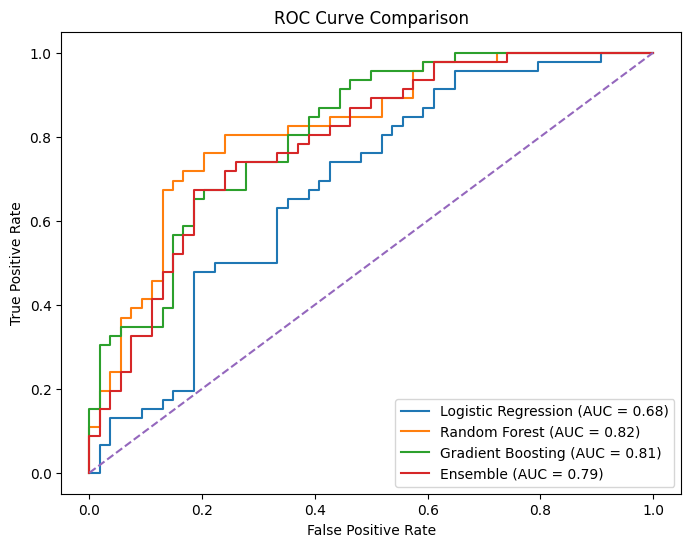

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8,6))

for name, model in models.items():
    # ใช้ probability ของ class = 1
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# เส้น baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# import joblib

# joblib.dump(model, 'heart_model.pkl')

['heart_model.pkl']

In [ ]:
# model = joblib.load('heart_model.pkl')